# Book - Modern Time Series Forecasting with Python

## Chapter 06 - ARIMA and SARIMA Models

### Python version 3.8

### Libraries version
* matplotlib: 3.7.1
* pandas: 2.0.3
* numpy: 1.24.4
* statsmodels: 0.14.1
* sklearn: 1.3.2
* scipy: 1.10.1
* seaborn: 0.13.2
* math
* itertools

#### Loading libries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import jarque_bera
from math import sqrt
import itertools

import warnings
warnings.filterwarnings('ignore')

## <span style="color:blue">Implementing ARIMA models in Python
### ARIMA Model Forecast for Johnson & Johnson Quarterly EPS

#### Load the Dataset

In [3]:
# Load Johnson & Johnson Quarterly EPS Data
url = "./Johnson & Johnson Quarterly EPS Data.csv"
jj_eps = pd.read_csv(url)
jj_eps.index = pd.date_range(start='1960-01-01', periods=len(jj_eps), freq='Q')
data_series = jj_eps['value']

#### Visualize the Original Data

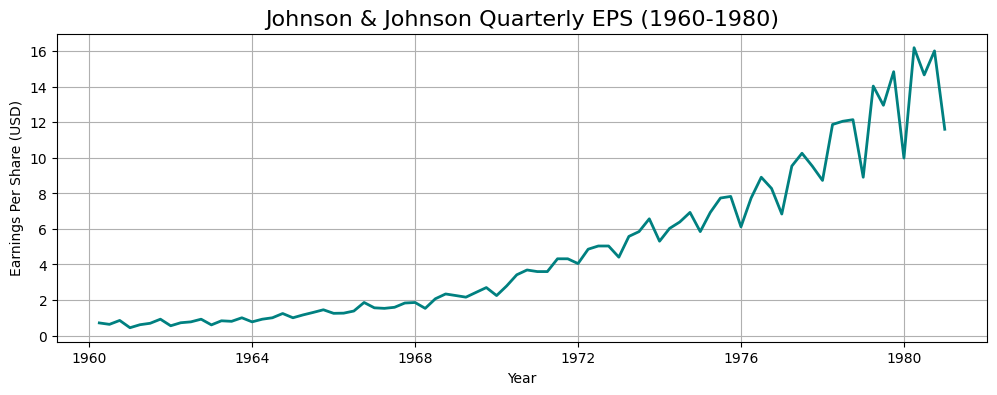

In [3]:
# Visualize the Original Data
plt.figure(figsize=(12, 4))
plt.plot(data_series, color='teal', linewidth=2)
plt.title('Johnson & Johnson Quarterly EPS (1960-1980)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Earnings Per Share (USD)')
plt.grid(True)
plt.show()

#### Stationarity Tests

In [4]:
#  Stationarity Tests
print("\n--- Stationarity Check (Original Series) ---")
# ADF Test
adf_stat, adf_p, _, _, _, _ = adfuller(data_series)
print(f"ADF Statistic (Original): {adf_stat:.4f}, p-value: {adf_p:.4f}")

# KPSS Test
kpss_stat, kpss_p, _, _ = kpss(data_series, regression='c', nlags='auto')
print(f"KPSS Statistic (Original): {kpss_stat:.4f}, p-value: {kpss_p:.4f}")


--- Stationarity Check (Original Series) ---
ADF Statistic (Original): 2.7420, p-value: 1.0000
KPSS Statistic (Original): 1.3635, p-value: 0.0100


#### Differencing and Stationarity Tests

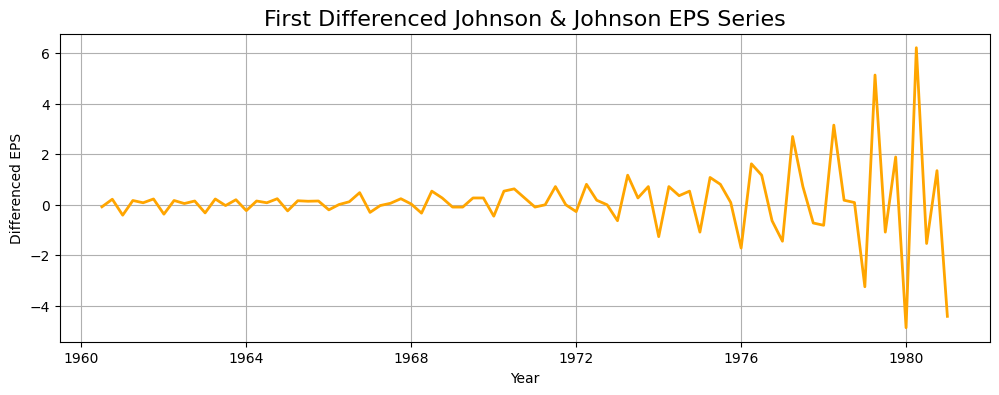

ADF Statistic (Differenced): -0.4074, p-value: 0.9089
KPSS Statistic (Differenced): 0.2214, p-value: 0.1000


In [5]:
# First Differencing (d=1)
differenced_series = data_series.diff().dropna()
plt.figure(figsize=(12, 4))
plt.plot(differenced_series, color='orange', linewidth=2)
plt.title('First Differenced Johnson & Johnson EPS Series', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Differenced EPS')
plt.grid(True)
plt.show()

# ADF and KPSS after Differencing
adf_stat_diff, adf_p_diff, _, _, _, _ = adfuller(differenced_series)
print(f"ADF Statistic (Differenced): {adf_stat_diff:.4f}, p-value: {adf_p_diff:.4f}")
kpss_stat_diff, kpss_p_diff, _, _ = kpss(differenced_series, regression='c', nlags='auto')
print(f"KPSS Statistic (Differenced): {kpss_stat_diff:.4f}, p-value: {kpss_p_diff:.4f}")

#### ACF and PACF for Model Identification

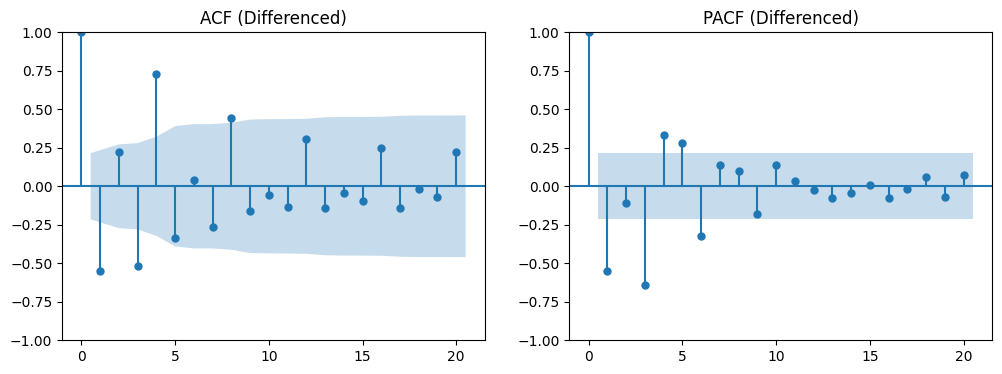

Best ARIMA Order: (4, 1, 4), AIC: 119.92


In [6]:
#ACF and PACF for Model Identification
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plot_acf(differenced_series, ax=plt.gca(), title='ACF (Differenced)')
plt.subplot(1, 2, 2)
plot_pacf(differenced_series, ax=plt.gca(), title='PACF (Differenced)')
plt.show()

# Model Selection (Grid Search for Best (p,d,q))
p = range(0, 5)
d = [1]  # Fixed at 1 based on differencing result
q = range(0, 5)
pdq_combinations = list(itertools.product(p, d, q))
best_aic = float('inf')
best_order = None

for order in pdq_combinations:
    try:
        model = ARIMA(data_series, order=order)
        model_fit = model.fit()
        if model_fit.aic < best_aic:
            best_aic = model_fit.aic
            best_order = order
    except:
        continue

print(f"Best ARIMA Order: {best_order}, AIC: {best_aic:.2f}")

#### Fitting the ARIMA Model

In [7]:
# Fit the Best Model
best_model = ARIMA(data_series, order=best_order)
best_model_fit = best_model.fit()
print(best_model_fit.summary())

# Diagnostic Checks
residuals = best_model_fit.resid

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                   84
Model:                 ARIMA(4, 1, 4)   Log Likelihood                 -50.959
Date:                Sun, 07 Dec 2025   AIC                            119.918
Time:                        11:19:50   BIC                            141.688
Sample:                    03-31-1960   HQIC                           128.664
                         - 12-31-1980                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0110      0.049     -0.226      0.822      -0.106       0.084
ar.L2         -0.0085      0.053     -0.160      0.873      -0.113       0.096
ar.L3          0.0632      0.044      1.434      0.1

#### Diagnostic Checking

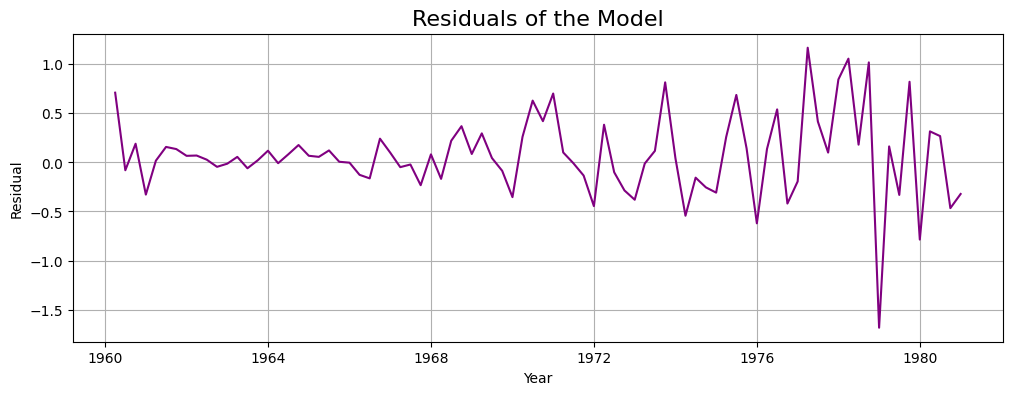

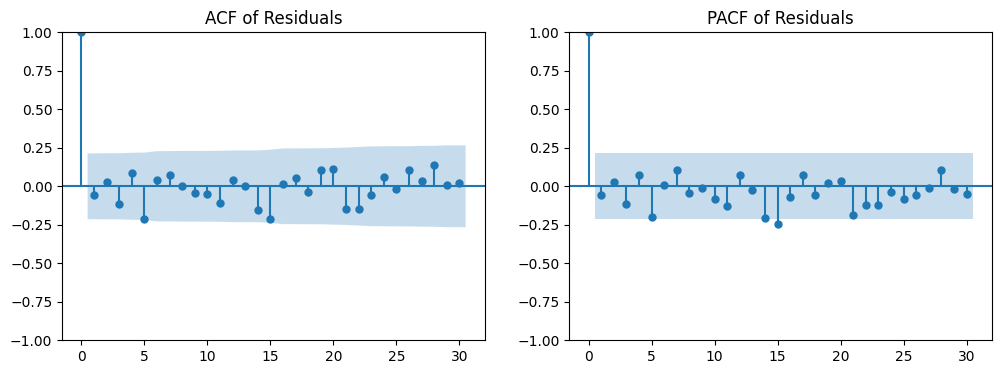

Jarque-Bera Test: Statistic = 37.5275, p-value = 0.0000


In [8]:
# Residual Analysis
plt.figure(figsize=(12, 4))
plt.plot(residuals, color='purple')
plt.title('Residuals of the Model', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Residual')
plt.grid(True)
plt.show()

# ACF and PACF of Residuals
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plot_acf(residuals, lags=30, ax=plt.gca(), title='ACF of Residuals')
plt.subplot(1, 2, 2)
plot_pacf(residuals, lags=30, ax=plt.gca(), title='PACF of Residuals')
plt.show()

# Normality Test
jb_stat, jb_p = jarque_bera(residuals)
print(f"Jarque-Bera Test: Statistic = {jb_stat:.4f}, p-value = {jb_p:.4f}")

#### Forecasting with the ARIMA Model


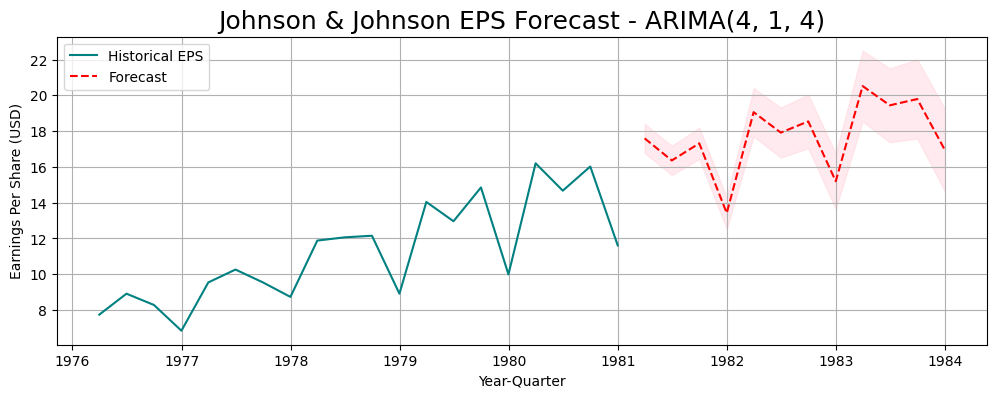

In [9]:
# Forecasting
forecast_steps = 12
forecast = best_model_fit.get_forecast(steps=forecast_steps)
forecast_df = forecast.summary_frame()

plt.figure(figsize=(12, 4))
plt.plot(data_series[-20:], label='Historical EPS', color='teal')
plt.plot(forecast_df.index, forecast_df['mean'], label='Forecast', color='red', linestyle='--')
plt.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'], color='pink', alpha=0.3)
plt.title(f'Johnson & Johnson EPS Forecast - ARIMA{best_order}', fontsize=18)
plt.xlabel('Year-Quarter')
plt.ylabel('Earnings Per Share (USD)')
plt.legend()
plt.grid(True)
plt.show()

#### Model Performance Evaluation

In [16]:
# Model Performance Evaluation
actual = data_series
predicted = best_model_fit.predict(start=0, end=len(data_series) - 1)

rmse = sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

RMSE: 0.42
MAE: 0.29


## <span style="color:blue">Implementing SARIMA models in Python
### SARIMA Model Forecast for Airline Passengers

#### Load the Dataset

In [18]:
print("--- Load and Visualize AirPassengers Data ---")
try:
    # Use the pre-packaged AirPassengers dataset from statsmodels
    air_passengers_data = sm.datasets.get_rdataset("AirPassengers", "datasets", cache=True).data
    # Ensure proper datetime indexing
    air_passengers_data['year'] = air_passengers_data['time'].astype(int)
    air_passengers_data['month'] = ((air_passengers_data['time'] - air_passengers_data['year']) * 12 + 1).round().astype(int)
    air_passengers_data['date'] = pd.to_datetime(air_passengers_data['year'].astype(str) + '-' + air_passengers_data['month'].astype(str))
    air_passengers_series = air_passengers_data.set_index('date')['value']
    air_passengers_series.index.freq = 'MS'
except Exception as e:
    print(f"Error loading AirPassengers dataset: {e}")
    print("Using fallback data.")
    # Fallback data
    dates_fallback = pd.date_range(start='1949-01-01', periods=144, freq='MS')
    air_passengers_series = pd.Series(np.sin(np.linspace(0, 2*np.pi*12, 144)) * 50 + np.linspace(100, 500, 144) + np.random.normal(0, 20, 144), index=dates_fallback)


--- Load and Visualize AirPassengers Data ---


#### Visualize Data

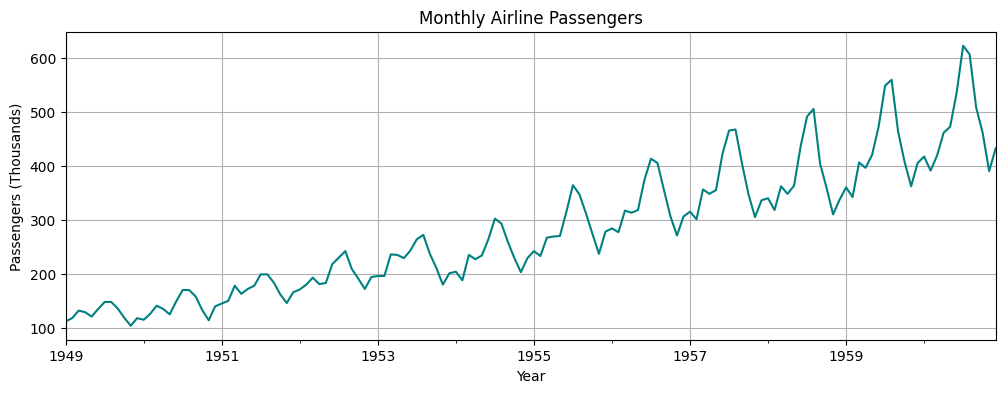

In [19]:
plt.figure(figsize=(12, 4))
air_passengers_series.plot(title='Monthly Airline Passengers', color='teal')
plt.xlabel('Year')
plt.ylabel('Passengers (Thousands)')
plt.grid(True)
plt.show()

#### Data Preparation & Stationarity Checks

In [20]:
# ---  Data Preparation ---
print("\n--- Data Preparation ---")
# Seasonal Differencing (s=12, D=1)
s = 12
air_D1 = air_passengers_series.diff(periods=s).dropna()
adf_D1 = adfuller(air_D1)
print(f'ADF p-value (after D=1): {adf_D1[1]:.4f}')  # Should be < 0.05 for stationarity

# Non-Seasonal Differencing (d=1) on the seasonally differenced series
air_D1_d1 = air_D1.diff().dropna()
adf_D1_d1 = adfuller(air_D1_d1)
print(f'ADF p-value (after D=1, d=1): {adf_D1_d1[1]:.4f}')  # Should be < 0.05


--- Data Preparation ---
ADF p-value (after D=1): 0.0116
ADF p-value (after D=1, d=1): 0.0000


#### Plot ACF and PACF for Model Identification


--- ACF/PACF of Fully Differenced Series ---


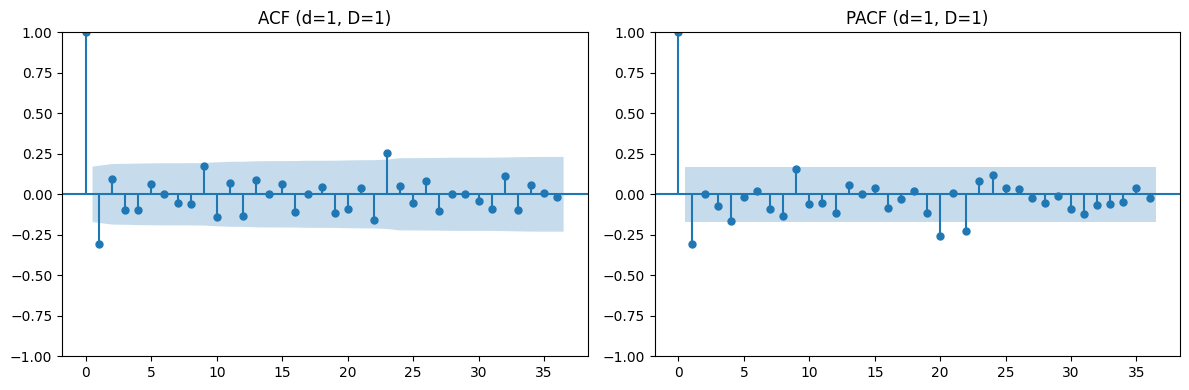

In [21]:
print("\n--- ACF/PACF of Fully Differenced Series ---")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(air_D1_d1, lags=36, ax=axes[0], title='ACF (d=1, D=1)')
plot_pacf(air_D1_d1, lags=36, ax=axes[1], method='ywm', title='PACF (d=1, D=1)')
plt.tight_layout()
plt.show()

#### Fitting the SARIMA Model (Parameter Estimation)

In [22]:
# --- Fit SARIMA Model ---
print("\n--- Fitting SARIMA Model ---")
p, q = 0, 2
P, Q = 1, 2
d, D = 1, 1


try:
    sarima_model = ARIMA(air_passengers_series, 
                         order=(p, d, q), 
                         seasonal_order=(P, D, Q, s),
                         enforce_stationarity=False,
                         enforce_invertibility=False)
    sarima_results = sarima_model.fit()
    print(sarima_results.summary())
    fit_successful = True
except Exception as e:
    print(f"Error fitting SARIMA model: {e}")
    fit_successful = False


--- Fitting SARIMA Model ---
                                    SARIMAX Results                                     
Dep. Variable:                            value   No. Observations:                  144
Model:             ARIMA(0, 1, 2)x(1, 1, 2, 12)   Log Likelihood                -404.496
Date:                          Sun, 07 Dec 2025   AIC                            820.992
Time:                                  11:23:44   BIC                            836.859
Sample:                              01-01-1949   HQIC                           827.420
                                   - 12-01-1960                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5275      0.075     -7.008      0.000      -0.675      -0.380
ma.L2          0.0433

#### Diagnostic Checking


--- Model Diagnostics ---


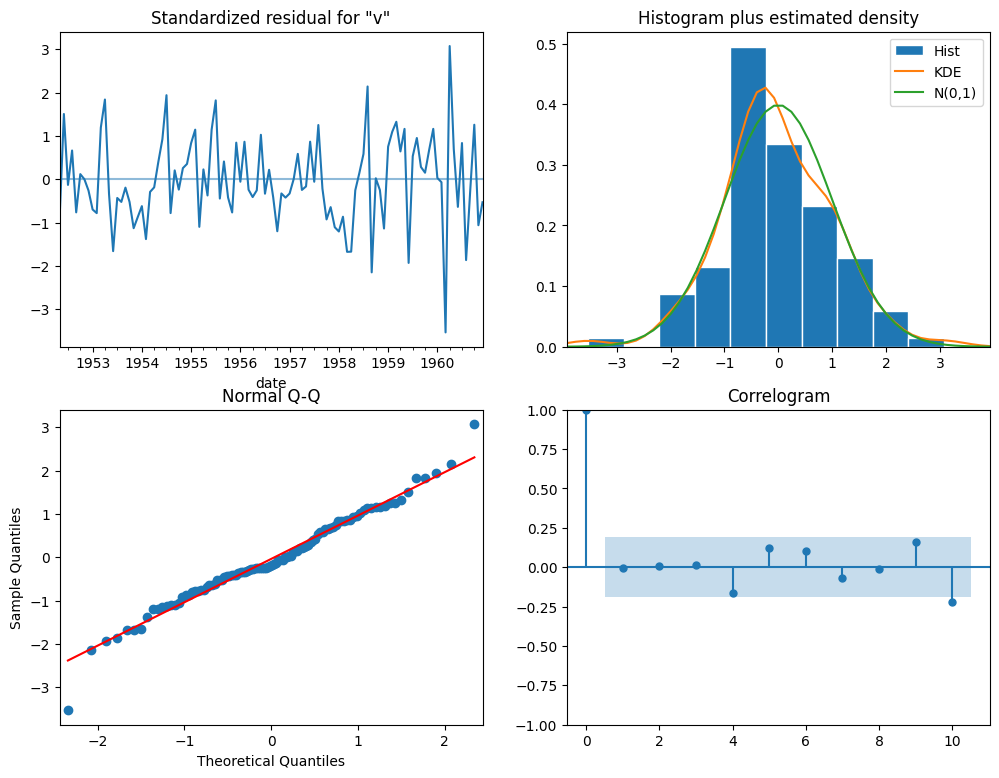


Ljung-Box Test on Residuals:
      lb_stat  lb_pvalue
12  38.754662   0.000115
24  49.581486   0.001600


In [25]:
# --- Model Diagnostics ---
if fit_successful:
    print("\n--- Model Diagnostics ---")
    sarima_results.plot_diagnostics(figsize=(12, 9))
    plt.show()

    # Check for residual autocorrelation
    lb_test = acorr_ljungbox(sarima_results.resid, lags=[12, 24], return_df=True)
    print("\nLjung-Box Test on Residuals:")
    print(lb_test)

#### Generate Forecasts


--- Generate and Evaluate Forecasts ---


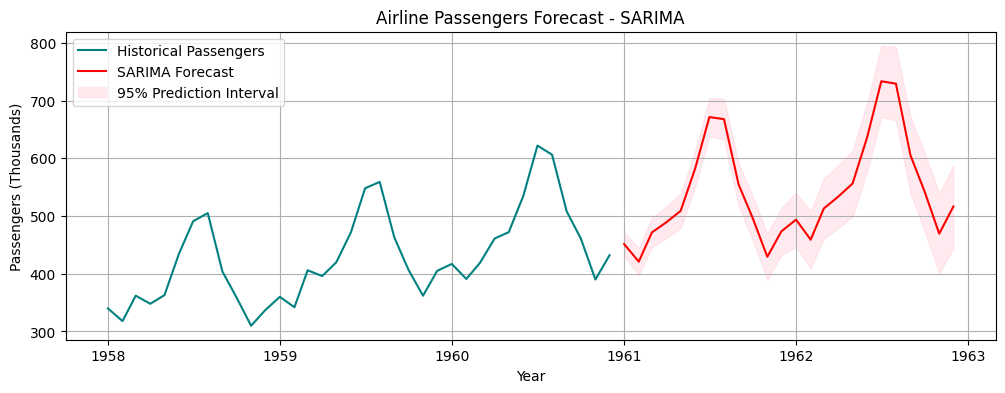

In [26]:
# --- Generate Forecasts ---
if fit_successful:
    print("\n--- Generate and Evaluate Forecasts ---")
    n_forecast = 24
    forecast_obj = sarima_results.get_forecast(steps=n_forecast)
    forecast_mean = forecast_obj.predicted_mean
    conf_int = forecast_obj.conf_int()

    # Plot Forecast
    plt.figure(figsize=(12, 4))
    plt.plot(air_passengers_series[-36:], label='Historical Passengers', color='teal')
    plt.plot(forecast_mean, label='SARIMA Forecast', color='red')
    plt.fill_between(conf_int.index, 
                     conf_int.iloc[:, 0], 
                     conf_int.iloc[:, 1], 
                     color='pink', alpha=0.3, label='95% Prediction Interval')
    plt.title('Airline Passengers Forecast - SARIMA')
    plt.xlabel('Year')
    plt.ylabel('Passengers (Thousands)')
    plt.legend()
    plt.grid(True)
    plt.show()

#### Model Performance Evaluation

In [27]:
# Model Performance Evaluation
actual = air_passengers_series#[-24:]
predicted = sarima_results.predict(start=0, end=len(air_passengers_series) - 1)#[-24:]

rmse = sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

RMSE: 18.06
MAE: 10.74
